# ADAML - NASA Turbofan A

**Team members:** Radomir Babek, Vojtech Vondracek, Jakub Rysanek

**Goal:** creation of KPLS models using 4 train/test datasets, predicting remaining useful life

In [11]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["PYTHONWARNINGS"] = (
    "ignore:y residual is constant at iteration:UserWarning:sklearn.cross_decomposition._pls"
)

import warnings
warnings.filterwarnings(
    "ignore",
    message=r"y residual is constant at iteration \d+",
    category=UserWarning,
    module=r"sklearn\.cross_decomposition\._pls"
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics.pairwise import rbf_kernel, laplacian_kernel, chi2_kernel
from sklearn.preprocessing import KernelCenterer
from sklearn.metrics import mean_squared_error, mean_absolute_error
from optimizer import optimize
from kernel import cauchy_kernel


## Data loading

In [12]:
def filter_no_variance(data):
    # Select only sensor columns
    sensor_cols = [col for col in data.columns if "sensor measurement" in col]

    # # Keep only sensors with non-zero variance and with their orig index
    valid_cols = []
    filtered_cols = []
    for i, col in enumerate(sensor_cols):
        if data[col].var() > 1e-8:
            valid_cols.append((i, col))
        else:
            filtered_cols.append(col)

    print("Zero variance columns (constant values):", filtered_cols)

    data = data.drop(columns=filtered_cols)
    return data, filtered_cols

def add_mean_max_min_column(data, window = 25):
  sensor_cols = [c for c in data.columns if "sensor measurement" in c]
  for i, col in enumerate(sensor_cols):
      # SM1_mean is mean of window values from sensor measurement 1
      data[f"SM{i+1}_mean" ] = data.groupby("unit number")[col].transform(
          lambda x: x.rolling(window=window, min_periods=1).mean()
      )
      data[f"SM{i+1}_max"] = data.groupby("unit number")[col].transform(
          lambda x: x.rolling(window=window, min_periods=1).max()
      )
      data[f"SM{i+1}_min"] = data.groupby("unit number")[col].transform(
          lambda x: x.rolling(window=window, min_periods=1).min()
      )

def from_file(train_file_name):
    names = [
      "unit number",
      "time, in cycles",
      "operational setting 1",
      "operational setting 2",
      "operational setting 3"
        ]

    sen_measurements = [f"sensor measurement {i}" for i in range(1, 22)]
    names = names + sen_measurements
    data = pd.read_csv(train_file_name, sep=r'\s+', names=names)

    return data

def train_from_file(file_name, validation_partition = 0.2):
    data = from_file(file_name)

    data, filtered_cols = filter_no_variance(data)
    add_mean_max_min_column(data)

    #COUNTING RUL
    units = dict(tuple(data.groupby("unit number")))
    new_units = []
    for u_id in units:
        u = units[u_id]
        u = u.drop(columns=[
                        "operational setting 1",
                        "operational setting 2",
                        "operational setting 3"])

        failure_time = u.shape[0] + 1
        u["RUL"] = failure_time - u["time, in cycles"]
        new_units.append(u)

    units = new_units

    # SPLITTING VALIDATION / TRAIN
    validation_unit_count = math.ceil(len(units) * validation_partition)
    np.random.seed(42)
    np.random.shuffle(units)

    validation_units = units[:validation_unit_count]
    train_units = units[validation_unit_count:]

    validation_data = pd.concat(validation_units)
    train_data = pd.concat(train_units)

    return train_data, validation_data, filtered_cols

def test_from_file(file_name, gt_file_name, dropped_cols):
    data = from_file(file_name)
    data = data.drop(columns=dropped_cols)

    add_mean_max_min_column(data)

    #read file, where there is only one number on a line into a vector of these numbers
    gt = np.loadtxt(gt_file_name)

    #COUNTING RUL
    units = dict(tuple(data.groupby("unit number")))
    new_units = []
    i = 0
    for u_id in units:
        u = units[u_id]
        u = u.drop(columns=[
                        "operational setting 1",
                        "operational setting 2",
                        "operational setting 3"])
        RUL = gt[i]
        u["RUL"] = int(RUL + u.shape[0] + 1) - u["time, in cycles"]
        i += 1
        new_units.append(u)

    units = new_units

    test_data = pd.concat(units)
    return test_data

## Data normalization

In [13]:
def normalizeRUL(Y, y_min, y_max):
    Y_scaled = (Y - y_min) / (y_max - y_min)
    return Y_scaled

def normalize_data(train_data, validation_data, test_data, normRUL=False):
    sensor_cols = [
        c for c in train_data.columns 
        if (("sensor measurement" in c) or ("mean" in c) or ("max" in c) or ("min" in c))
        and c not in ["unit number", "time_in_cycles"]
    ]
    print(sensor_cols)

    mu_train = train_data[sensor_cols].mean(axis=0)
    sd_train = train_data[sensor_cols].std(axis=0, ddof=0)

    sd_r = sd_train.replace(0, 1)  # prevence dělení nulou

    train_data[sensor_cols]      = (train_data[sensor_cols     ] - mu_train) / sd_r
    validation_data[sensor_cols] = (validation_data[sensor_cols] - mu_train) / sd_r
    test_data[sensor_cols]       = (test_data[sensor_cols      ] - mu_train) / sd_r

    #Normalize RUL
    if normRUL==True:
        y_min, y_max = train_data["RUL"].min(), train_data["RUL"].max()
        train_data["RUL"] = normalizeRUL(train_data["RUL"], y_min, y_max)
        validation_data["RUL"] = normalizeRUL(validation_data["RUL"], y_min, y_max)
        test_data["RUL"] = normalizeRUL(test_data["RUL"], y_min, y_max)

    return train_data, validation_data, test_data, mu_train, sd_train

## KPLS

In [14]:
def fit_model(X,y, n_lv, kernel_f, gamma):
    K_train = kernel_f(X, X, gamma=gamma)
    centerer = KernelCenterer()
    K_train_c = centerer.fit_transform(K_train)
    
    pls = PLSRegression(n_lv, scale=False)
    pls.fit(K_train_c, y)
    return pls, centerer

def count_q2(y_val, y_pred, y_train):
    ss_res = np.sum((y_val - y_pred.ravel())**2) 
    ss_tot = np.sum((y_val - np.mean(y_train))**2)
    return 1 - ss_res/ss_tot 

def predict(X_train, y_train, X, y, pls, centerer, gamma, kernel_f):
    K_validation   = kernel_f(X, X_train, gamma=gamma)
    K_validation_c = centerer.transform(K_validation)
    y_pred = pls.predict(K_validation_c).ravel()

    rmse = np.sqrt(mean_squared_error(y, y_pred))
    mae  = mean_absolute_error(y, y_pred)
    q2   = count_q2(y, y_pred, y_train)

    return rmse, mae, q2


def fit_kpls(train_data, validation_data, kernel_f=rbf_kernel, method_name="RBF_kernel", max_lv=13, use_train_cv=True, parallel=False):
    output = []

    if use_train_cv:
        opt_data = train_data
    else:
        opt_data = validation_data

    # optimize gamma on training data
    opt_results = optimize(opt_data, max_lv, folds=3, kernel_f=kernel_f, method_name=method_name, parallel=parallel)
    best_row = opt_results.loc[opt_results["q2"].idxmax()]
    print(f"Best TRAIN n_lv={int(best_row.n_lv)}, gamma={best_row.gamma:.6g}, Q^2={best_row.q2:.4f}")
    
    # prepare datasets with only sensor data
    X_train = train_data.iloc[:, 2:-1]
    y_train = train_data.iloc[:, -1]

    X_validation = validation_data.iloc[:, 2:-1]
    y_validation = validation_data.iloc[:, -1]

    # eval validation (or the remaining unseen) dataset - test for generalization
    for _,res in opt_results.iterrows():
        gamma = res["gamma"]
        n_lv = int(res["n_lv"])

        train_q2   = res["q2"]
        pls, centerer = fit_model(X_train, y_train, n_lv, kernel_f, gamma)

        validation_rmse, validation_mae, validation_q2 = predict(
            X_train, y_train, X_validation, y_validation, pls, centerer, gamma, kernel_f)

        output.append({
            "n_lv": n_lv,
            "gamma": gamma,
            "q2_validation": validation_q2,
            "q2_train_cv": train_q2,
            "rmse_val": validation_rmse,
            "mae_val": validation_mae,
            "method_name": method_name,
            "kernel_f": kernel_f
        })

    return pd.DataFrame(output)

def eval_test(test_data, train_data, train_results, kernel_f, method_name):
    X_train = train_data.iloc[:, 2:-1]
    y_train = train_data.iloc[:, -1]
    X_test = test_data.iloc[:, 2:-1]
    y_test = test_data.iloc[:, -1]

    best_row_train = train_results.loc[train_results["q2_train_cv"].idxmax()]
    best_row_val = train_results.loc[train_results["q2_validation"].idxmax()]

    def eval_row(row):
        gamma = row["gamma"]
        n_lv = int(row["n_lv"])
        pls, centerer = fit_model(X_train, y_train, n_lv, kernel_f, gamma)
        rmse, mae, q2 = predict(X_train, y_train, X_test, y_test, pls, centerer, gamma, kernel_f)

        test_row = row.copy()
        test_row["rmse_test"] = rmse
        test_row["mae_test"] = mae
        test_row["q2_test"] = q2
        test_row["method"] = f"{method_name}"
        return test_row

    output = [eval_row(best_row_train)]

    if best_row_train.name != best_row_val.name:
        output.append(eval_row(best_row_val))

    return pd.DataFrame(output)

def plot_unit(train_data, test_data, params, dataset_name, unit_id):
    gamma = params.gamma
    n_lv = params.n_lv
    kernel_f = params.kernel_f
    method = params.method_name

    X_train = train_data.iloc[:, 2:-1]
    y_train = train_data.iloc[:, -1]

    pls, centerer = fit_model(X_train, y_train, n_lv, kernel_f, gamma)
    test_unit = test_data[test_data["unit number"] == unit_id]

    Xunit = test_unit.iloc[:, 2:-1].to_numpy()
    K_unit = kernel_f(Xunit, X_train, gamma=gamma)
    Kunit_c = centerer.transform(K_unit)
    Yunit = test_unit["RUL"].to_numpy()

    # Predict
    Ypred = pls.predict(Kunit_c).ravel()
    Ypred = np.clip(Ypred, 0, None)

    rmse_unit = np.sqrt(mean_squared_error(Yunit, Ypred))

    plt.figure(figsize=(5, 5))
    plt.scatter(Yunit, Ypred, s=15, c="tab:blue", alpha=0.7)
    plt.plot([Yunit.min(), Yunit.max()], [Yunit.min(), Yunit.max()], "k--", lw=1.2)
    plt.xlabel("Observed RUL")
    plt.ylabel("Predicted RUL")

    plt.title(
        f"{dataset_name} — Unit {unit_id}\n"
        f"{method}, γ={gamma:.3g}, RMSE={rmse_unit:.3f}"
    )

    plt.grid(True)
    plt.axis("equal")
    plt.tight_layout()
    plt.show()

def process_dataset(train_data, validation_data, test_data, dataset_name, use_train_cv=True, parallel=False):
    print("RBF kernel")
    train_results_rbf = fit_kpls(train_data, validation_data, kernel_f=rbf_kernel, method_name="RBF", max_lv=12, use_train_cv=use_train_cv, parallel=parallel)
    test_results_rbf = eval_test(test_data, train_data, train_results_rbf, kernel_f=rbf_kernel, method_name="RBF")

    print("Laplacian kernel")
    train_results_laplac = fit_kpls(train_data, validation_data, kernel_f=laplacian_kernel, method_name="Laplacian", max_lv=12, use_train_cv=use_train_cv, parallel=parallel)
    test_results_laplac = eval_test(test_data, train_data, train_results_laplac, kernel_f=laplacian_kernel, method_name="Laplacian")

    print("Cauchy kernel")
    train_results_cauchy = fit_kpls(train_data, validation_data, kernel_f=cauchy_kernel, method_name="Cauchy", max_lv=12, use_train_cv=use_train_cv, parallel=parallel)
    test_results_cauchy = eval_test(test_data, train_data, train_results_cauchy, kernel_f=cauchy_kernel, method_name="Cauchy")

    train_results_all = pd.concat(
        [train_results_rbf, train_results_laplac, train_results_cauchy],
        ignore_index=True
    )
    train_results_all.drop(columns=["kernel_f"], inplace=True)
    train_results_all.to_csv(dataset_name + "_train.csv")

    test_results_all = pd.concat(
        [test_results_rbf, test_results_laplac, test_results_cauchy],
        ignore_index=True
    )

    best_row_train = test_results_all.loc[test_results_all["rmse_test"].idxmin()]

    units_to_plot = [20, 40, 80]
    for unit_id in units_to_plot:
        plot_unit(train_data, test_data, best_row_train, dataset_name, unit_id)
    
    test_results_all.drop(columns=["kernel_f"], inplace=True)
    test_results_all.to_csv(dataset_name + "_test.csv")

## Modeling and evaluation

Zero variance columns (constant values): ['sensor measurement 1', 'sensor measurement 5', 'sensor measurement 10', 'sensor measurement 16', 'sensor measurement 18', 'sensor measurement 19']
['sensor measurement 2', 'sensor measurement 3', 'sensor measurement 4', 'sensor measurement 6', 'sensor measurement 7', 'sensor measurement 8', 'sensor measurement 9', 'sensor measurement 11', 'sensor measurement 12', 'sensor measurement 13', 'sensor measurement 14', 'sensor measurement 15', 'sensor measurement 17', 'sensor measurement 20', 'sensor measurement 21', 'SM1_mean', 'SM1_max', 'SM1_min', 'SM2_mean', 'SM2_max', 'SM2_min', 'SM3_mean', 'SM3_max', 'SM3_min', 'SM4_mean', 'SM4_max', 'SM4_min', 'SM5_mean', 'SM5_max', 'SM5_min', 'SM6_mean', 'SM6_max', 'SM6_min', 'SM7_mean', 'SM7_max', 'SM7_min', 'SM8_mean', 'SM8_max', 'SM8_min', 'SM9_mean', 'SM9_max', 'SM9_min', 'SM10_mean', 'SM10_max', 'SM10_min', 'SM11_mean', 'SM11_max', 'SM11_min', 'SM12_mean', 'SM12_max', 'SM12_min', 'SM13_mean', 'SM13_max',

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
python(32788) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(32789) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(32790) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(32791) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


n_lv: 2, gamma: 0.0425704064038881, q2: 0.42528644661355
n_lv: 1, gamma: 0.0005325555567403421, q2: 0.48450489414603976
n_lv: 3, gamma: 0.0032741012270299857, q2: 0.5545583535422424
n_lv: 4, gamma: 0.002795124109398102, q2: 0.6166945063153764
n_lv: 5, gamma: 0.0047031852676665716, q2: 0.6229576400865349


[Parallel(n_jobs=4)]: Done   5 tasks      | elapsed:  2.4min


n_lv: 6, gamma: 0.003734475229186615, q2: 0.6283730299523492
n_lv: 7, gamma: 0.01835696459723847, q2: 0.62130687078611


[Parallel(n_jobs=4)]: Done   7 out of  12 | elapsed:  2.6min remaining:  1.9min


n_lv: 8, gamma: 0.006788391207866422, q2: 0.629610776754921
n_lv: 9, gamma: 0.0079101692085904, q2: 0.628803484307548


[Parallel(n_jobs=4)]: Done   9 out of  12 | elapsed:  4.0min remaining:  1.3min


n_lv: 10, gamma: 0.009038260382157168, q2: 0.6266608159471533
n_lv: 11, gamma: 0.00758916988865477, q2: 0.6221072176172404
n_lv: 12, gamma: 0.011281412140627951, q2: 0.6180197542921224


[Parallel(n_jobs=4)]: Done  12 out of  12 | elapsed:  4.6min finished


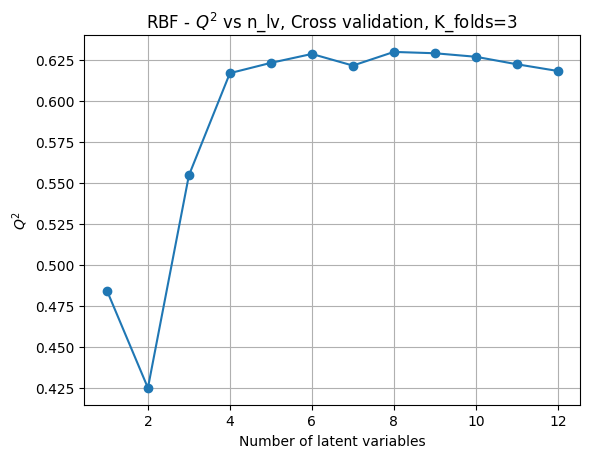

Best TRAIN n_lv=8, gamma=0.00678839, Q^2=0.6296
Laplacian kernel
Gamma bounds: (1.843393022035742e-05; 18.433930220357418)
Optimizer starts...


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


n_lv: 1, gamma: 7.041494200498219, q2: 2.220446049250313e-16
n_lv: 2, gamma: 7.041494200498219, q2: 2.220446049250313e-16
n_lv: 3, gamma: 7.041494200498219, q2: 2.220446049250313e-16
n_lv: 4, gamma: 7.041494200498219, q2: 2.220446049250313e-16
n_lv: 5, gamma: 7.041494200498219, q2: 2.220446049250313e-16


[Parallel(n_jobs=4)]: Done   5 tasks      | elapsed:  4.4min


n_lv: 6, gamma: 7.041494200498219, q2: 2.220446049250313e-16
n_lv: 8, gamma: 9.078598774661446, q2: 2.220446049250313e-16


[Parallel(n_jobs=4)]: Done   7 out of  12 | elapsed:  4.8min remaining:  3.4min


n_lv: 7, gamma: 7.039594143081753, q2: 2.7755575615628914e-16
n_lv: 9, gamma: 9.078598774661446, q2: 2.220446049250313e-16


[Parallel(n_jobs=4)]: Done   9 out of  12 | elapsed:  7.0min remaining:  2.3min


n_lv: 10, gamma: 9.078598517493063, q2: 2.220446049250313e-16
n_lv: 11, gamma: 9.078598517493063, q2: 2.220446049250313e-16
n_lv: 12, gamma: 9.078598517493063, q2: 2.220446049250313e-16


[Parallel(n_jobs=4)]: Done  12 out of  12 | elapsed:  7.6min finished


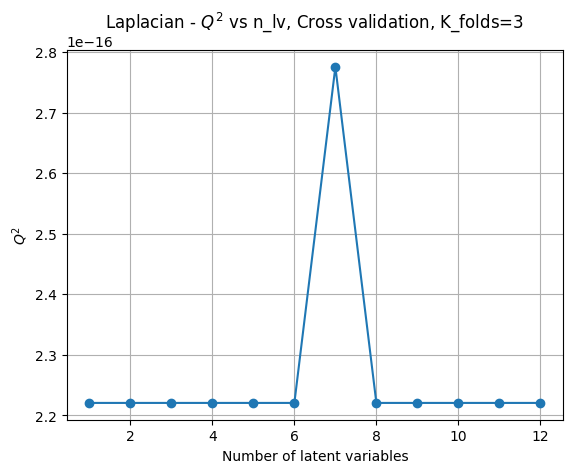

Best TRAIN n_lv=7, gamma=7.03959, Q^2=0.0000
Cauchy kernel
Gamma bounds: (1.3778612908172602e-05; 13.778612908172603)
Optimizer starts...


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


n_lv: 4, gamma: 8.451429308814431, q2: 0.549169825498389
n_lv: 3, gamma: 11.61874158217542, q2: 0.4850028324327988
n_lv: 1, gamma: 13.778049964917718, q2: 0.3511043932469147
n_lv: 2, gamma: 13.778049964917718, q2: 0.4414779527411162
n_lv: 6, gamma: 1.6307552889356263, q2: 0.6034014765213598


[Parallel(n_jobs=4)]: Done   5 tasks      | elapsed:  1.6min


n_lv: 5, gamma: 0.007268755645441535, q2: 0.6231949122011138
n_lv: 9, gamma: 2.6461645545511336, q2: 0.5910431833112998


[Parallel(n_jobs=4)]: Done   7 out of  12 | elapsed:  2.5min remaining:  1.8min


n_lv: 8, gamma: 0.04821296542308415, q2: 0.6219883698470693
n_lv: 10, gamma: 2.696006058413146, q2: 0.5913964450166767


[Parallel(n_jobs=4)]: Done   9 out of  12 | elapsed:  2.8min remaining:   55.7s


n_lv: 7, gamma: 0.002961387762959877, q2: 0.6327386940278988
n_lv: 11, gamma: 2.2985409506451107, q2: 0.5947739142398559
n_lv: 12, gamma: 2.836684885547117, q2: 0.5929941472345814


[Parallel(n_jobs=4)]: Done  12 out of  12 | elapsed:  3.5min finished


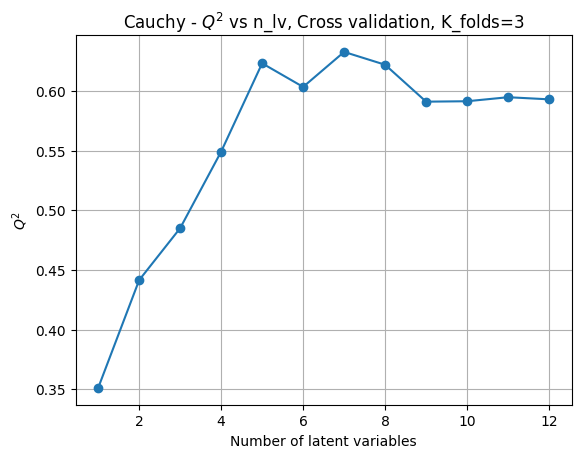

Best TRAIN n_lv=7, gamma=0.00296139, Q^2=0.6327


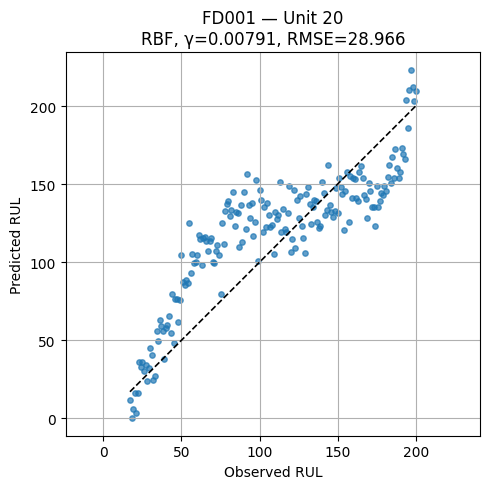

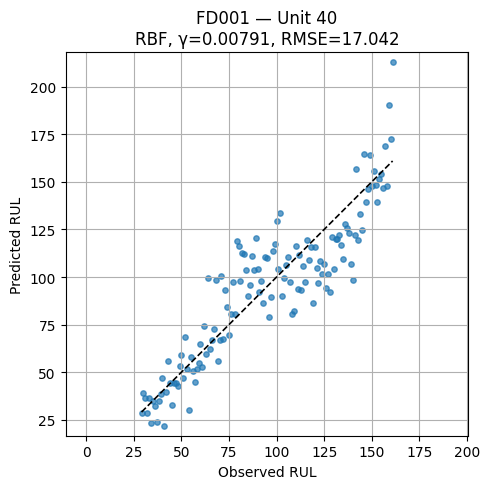

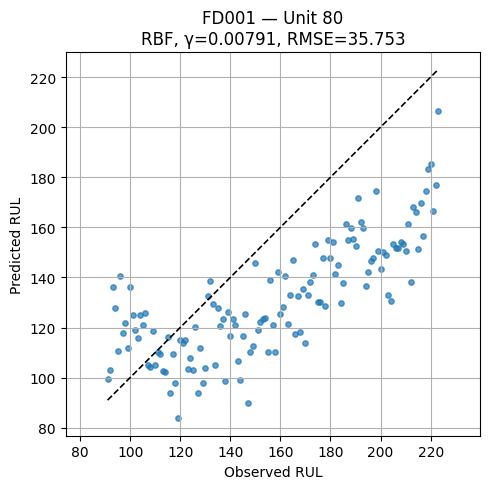

Zero variance columns (constant values): []
['sensor measurement 1', 'sensor measurement 2', 'sensor measurement 3', 'sensor measurement 4', 'sensor measurement 5', 'sensor measurement 6', 'sensor measurement 7', 'sensor measurement 8', 'sensor measurement 9', 'sensor measurement 10', 'sensor measurement 11', 'sensor measurement 12', 'sensor measurement 13', 'sensor measurement 14', 'sensor measurement 15', 'sensor measurement 16', 'sensor measurement 17', 'sensor measurement 18', 'sensor measurement 19', 'sensor measurement 20', 'sensor measurement 21', 'SM1_mean', 'SM1_max', 'SM1_min', 'SM2_mean', 'SM2_max', 'SM2_min', 'SM3_mean', 'SM3_max', 'SM3_min', 'SM4_mean', 'SM4_max', 'SM4_min', 'SM5_mean', 'SM5_max', 'SM5_min', 'SM6_mean', 'SM6_max', 'SM6_min', 'SM7_mean', 'SM7_max', 'SM7_min', 'SM8_mean', 'SM8_max', 'SM8_min', 'SM9_mean', 'SM9_max', 'SM9_min', 'SM10_mean', 'SM10_max', 'SM10_min', 'SM11_mean', 'SM11_max', 'SM11_min', 'SM12_mean', 'SM12_max', 'SM12_min', 'SM13_mean', 'SM13_max

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


n_lv: 1, gamma: 1.0778666828464356, q2: 0.14672471804090903
n_lv: 2, gamma: 0.6538414584708873, q2: 0.22431706047532357
n_lv: 3, gamma: 0.44313245261749085, q2: 0.2937833729356611
n_lv: 4, gamma: 0.1542893776159408, q2: 0.34769628050374646
n_lv: 5, gamma: 0.13052821537156892, q2: 0.38033097391267207


[Parallel(n_jobs=4)]: Done   5 tasks      | elapsed:   45.6s


n_lv: 6, gamma: 0.2642854730245862, q2: 0.4093461153961764
n_lv: 7, gamma: 0.22047936024770184, q2: 0.4328022363850012


[Parallel(n_jobs=4)]: Done   7 out of  12 | elapsed:   47.7s remaining:   34.1s


n_lv: 8, gamma: 0.18271818154022998, q2: 0.451393426545474
n_lv: 9, gamma: 0.18034950977916456, q2: 0.46057637122911677


[Parallel(n_jobs=4)]: Done   9 out of  12 | elapsed:  1.4min remaining:   28.1s


n_lv: 11, gamma: 0.1276151800317173, q2: 0.47499027002241895
n_lv: 10, gamma: 0.1354784669888575, q2: 0.47167856957659987
n_lv: 12, gamma: 0.00044982851553448055, q2: 0.5968538256690092


[Parallel(n_jobs=4)]: Done  12 out of  12 | elapsed:  1.9min finished


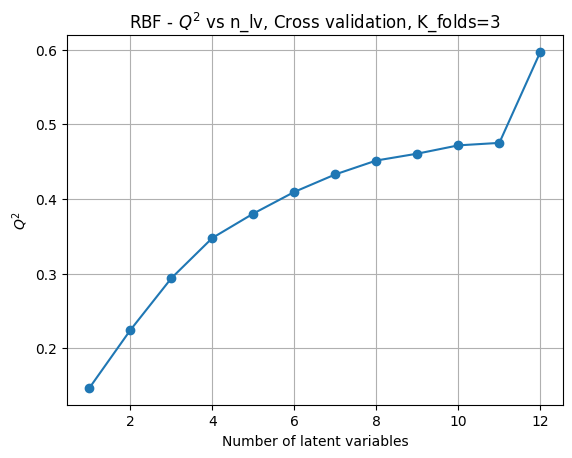

Best TRAIN n_lv=12, gamma=0.000449829, Q^2=0.5969
Laplacian kernel
Gamma bounds: (2.005205654252349e-05; 20.052056542523488)
Optimizer starts...


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
python(46582) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(46583) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(46584) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(46585) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


n_lv: 1, gamma: 14.537216503521504, q2: 1.4856422148046278e-07
n_lv: 3, gamma: 13.799799648753206, q2: 1.522996786462727e-07
n_lv: 4, gamma: 13.799145638353316, q2: 1.5227061217482074e-07
n_lv: 2, gamma: 13.724750718120253, q2: 1.5295630240164115e-07
n_lv: 5, gamma: 13.798262642207554, q2: 1.5228199912176166e-07


[Parallel(n_jobs=4)]: Done   5 tasks      | elapsed:  1.3min


n_lv: 6, gamma: 13.798318240575625, q2: 1.5228148103618722e-07
n_lv: 7, gamma: 13.79832088629773, q2: 1.5228146288404076e-07


[Parallel(n_jobs=4)]: Done   7 out of  12 | elapsed:  1.4min remaining:   59.0s


n_lv: 8, gamma: 13.798320341433032, q2: 1.5228146599266523e-07
n_lv: 9, gamma: 13.798320410147028, q2: 1.5228146593715408e-07


[Parallel(n_jobs=4)]: Done   9 out of  12 | elapsed:  2.0min remaining:   41.0s


n_lv: 10, gamma: 13.79832027304137, q2: 1.5228146582613178e-07
n_lv: 11, gamma: 13.798320060051195, q2: 1.5228146571510948e-07
n_lv: 12, gamma: 13.79832021588824, q2: 1.5228146582613178e-07


[Parallel(n_jobs=4)]: Done  12 out of  12 | elapsed:  2.3min finished


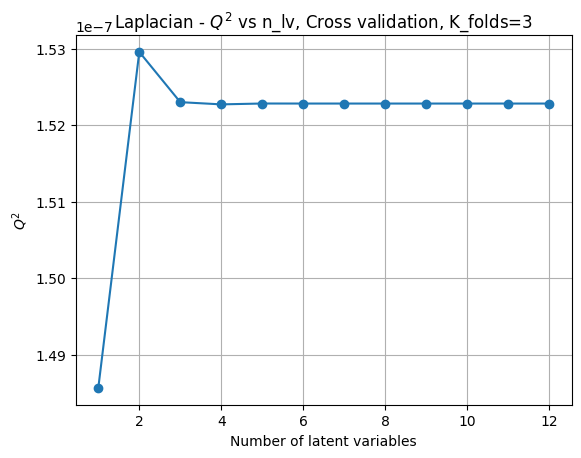

Best TRAIN n_lv=2, gamma=13.7248, Q^2=0.0000


KeyboardInterrupt: 

: 

In [ ]:
train_data1, validation_data1, dropped_cols1 = train_from_file("./NASA-Turbofan-data/data/train_FD001.txt")
test_data1 = test_from_file("./NASA-Turbofan-data/data/test_FD001.txt", "./NASA-Turbofan-data/data/RUL_FD001.txt", dropped_cols=dropped_cols1)
train_data1, validation_data1, test_data1, mu_train1, sd_train1 = normalize_data(train_data1, validation_data1, test_data1)
process_dataset(train_data1, validation_data1, test_data1, "FD001", use_train_cv=True, parallel=True)

train_data2, validation_data2, dropped_cols2 = train_from_file("./NASA-Turbofan-data/data/train_FD002.txt")
test_data2 = test_from_file("./NASA-Turbofan-data/data/test_FD002.txt", "./NASA-Turbofan-data/data/RUL_FD002.txt", dropped_cols=dropped_cols2)
train_data2, validation_data2, test_data2, mu_train2, sd_train2 = normalize_data(train_data2, validation_data2, test_data2)
process_dataset(train_data2, validation_data2, test_data2, "FD002", use_train_cv=False, parallel=True)

train_data3, validation_data3, dropped_cols3 = train_from_file("./NASA-Turbofan-data/data/train_FD003.txt")
test_data3 = test_from_file("./NASA-Turbofan-data/data/test_FD003.txt", "./NASA-Turbofan-data/data/RUL_FD003.txt", dropped_cols=dropped_cols3)
train_data3, validation_data3, test_data3, mu_train3, sd_train3 = normalize_data(train_data3, validation_data3, test_data3)
process_dataset(train_data3, validation_data3, test_data3, "FD003", use_train_cv=True, parallel=True)

train_data4, validation_data4, dropped_cols4 = train_from_file("./NASA-Turbofan-data/data/train_FD004.txt")
test_data4 = test_from_file("./NASA-Turbofan-data/data/test_FD004.txt", "./NASA-Turbofan-data/data/RUL_FD004.txt", dropped_cols=dropped_cols4)
train_data4, validation_data4, test_data4, mu_train4, sd_train4 = normalize_data(train_data4, validation_data4, test_data4)
process_dataset(train_data4, validation_data4, test_data4, "FD004", use_train_cv=False, parallel=True)